
# Model Comparison Notebook (Residual + Prior + Full Lookup + Retrain)

這份 notebook 重新整理成一個比較公平的版本：

- **五個模型全部重訓**，不再 `load pkl`
- **Residual target**：所有模型都預測 `y_target = log1p(count) - base_log`
- **Prior / baseline**：先用 train split 建立 `base_log / freq_nz`
- **Custom features by model**
  - **LSTM / GRU / LightGBM**：使用和 ConvLSTM 相同邏輯的 8 個 offsets  
    `(0,-1)...(0,-6), (-1,0), (-7,0)`
  - **ConvLSTM / PredRNN**：使用 patch sequence + 同一組 offsets
- **Full lookup**：只對 ConvLSTM / PredRNN 類 patch 模型使用，因為它們需要 cube 查歷史；  
  LSTM / GRU / LightGBM 直接使用已展開好的特徵欄位，不另外做 full lookup
- **Prior mask**：只對 ConvLSTM / PredRNN 啟用，因為 `freq_prior_df` 只在 `train_convlstm_embed()` 這條 pipeline 裡有實際作用

> 你需要確保專案的 `src/` 可以正常 import。  
> 若 `lightgbm` 尚未安裝，請先安裝後再執行。


In [1]:

import os
import sys
import importlib
import warnings

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

sys.path.append(os.path.abspath(".."))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device:", device)
print("cwd:", os.getcwd())


using device: cuda
cwd: c:\Users\Radimon\2025_japan_people_flow\notebooks


In [2]:
# 1. 載入資料與通用工具
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEQ_LEN = 8
DATA_PATH = "../data/processed/sapporo_density.parquet"
ORIGIN_DATE = pd.Timestamp("2019-09-15")  # d=0
TEST_DAYS = 7
VAL_DAYS = 7

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def smape(y_true, y_pred, eps=1e-9):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(2*np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)) * 100)

def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

def eval_metrics(name, y_true, y_pred):
    return {
        "Model": name,
        "RMSE": rmse(y_true, y_pred),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R²": float(r2_score(y_true, y_pred)),
        "MAPE(%)": safe_mape(y_true, y_pred),
        "SMAPE(%)": smape(y_true, y_pred),
    }

def split_by_day(df, test_days=7, val_days=7):
    max_day = int(df["d"].max())
    test_start = max_day - test_days + 1
    val_start  = test_start - val_days

    train_df = df[df["d"] < val_start].copy()
    val_df   = df[(df["d"] >= val_start) & (df["d"] < test_start)].copy()
    test_df  = df[df["d"] >= test_start].copy()

    return train_df, val_df, test_df

def prepare_base_df(parquet_path, remove_sentinel=True):
    df = pd.read_parquet(parquet_path).copy()
    if remove_sentinel:
        df = df[~((df["x"] == 999) & (df["y"] == 999))].copy()
    return df


def add_calendar_features(df: pd.DataFrame, origin_date: str | pd.Timestamp = ORIGIN_DATE) -> pd.DataFrame:
    df = df.copy()
    origin_date = pd.Timestamp(origin_date)

    df["date"] = origin_date + pd.to_timedelta(df["d"].astype(int), unit="D")
    df["weekday"] = df["date"].dt.weekday.astype(np.int16)
    df["is_weekend"] = (df["weekday"] >= 5).astype(np.int8)
    df["month"] = df["date"].dt.month.astype(np.int16)

    season = np.zeros(len(df), dtype=np.int16)
    m = df["month"].to_numpy()
    season[(m >= 3) & (m <= 5)] = 1
    season[(m >= 6) & (m <= 8)] = 2
    season[(m >= 9) & (m <= 11)] = 3
    df["season"] = season

    return df

def build_priors(train_df: pd.DataFrame, keys: list[str], alpha: float = 1.0) -> pd.DataFrame:
    g = train_df.groupby(keys, as_index=False)
    agg = g["count"].agg(
        n="size",
        nz=lambda s: int((s.to_numpy() > 0).sum()),
        base_log=lambda s: float(np.log1p(s.to_numpy()).mean()),
    )
    agg["freq_nz"] = (agg["nz"] + alpha) / (agg["n"] + 2 * alpha)
    return agg[keys + ["freq_nz", "base_log"]]

def attach_priors_with_backoff(df: pd.DataFrame,
                              priA: pd.DataFrame, keysA: list[str],
                              priB: pd.DataFrame, keysB: list[str],
                              priC: pd.DataFrame, keysC: list[str]) -> pd.DataFrame:
    df = df.copy()

    df = df.merge(priA, on=keysA, how="left", suffixes=("", "_A"))
    df = df.merge(priB, on=keysB, how="left", suffixes=("", "_B"))
    df = df.merge(priC, on=keysC, how="left", suffixes=("", "_C"))

    df["base_log"] = (
        df["base_log"]
        .combine_first(df["base_log_B"])
        .combine_first(df["base_log_C"])
        .fillna(0.0)
        .astype(np.float32)
    )

    df["freq_nz"] = (
        df["freq_nz"]
        .combine_first(df["freq_nz_B"])
        .combine_first(df["freq_nz_C"])
        .fillna(0.0)
        .astype(np.float32)
    )

    drop_cols = [c for c in df.columns if c.endswith("_B") or c.endswith("_C")]
    df.drop(columns=drop_cols, inplace=True)

    return df


In [3]:
# 2. 用和 ConvLSTM / PredRNN 相同 offset 建 tabular lag features
def add_lags_and_rollings_custom(df: pd.DataFrame, seq_len: int = 8, origin_date: str | pd.Timestamp = ORIGIN_DATE) -> pd.DataFrame:
    '''
    Build lag_1..lag_8 exactly aligned with ConvLSTM offsets:
      lag_1..lag_6 = same day previous 1~6 time slots
      lag_7        = previous day same time slot
      lag_8        = previous week same time slot
    '''
    if seq_len != 8:
        raise ValueError(f"This custom version is designed for seq_len=8, got seq_len={seq_len}")

    df = add_calendar_features(df.copy(), origin_date=origin_date)

    base = df[["d", "t", "x", "y", "count"]].copy()
    offsets = [
        (0, -1), (0, -2), (0, -3), (0, -4),
        (0, -5), (0, -6), (-1, 0), (-7, 0),
    ]

    for i, (d_shift, t_shift) in enumerate(offsets, start=1):
        tmp = base.copy()
        tmp["d"] = tmp["d"] - d_shift
        tmp["t"] = tmp["t"] - t_shift
        tmp = tmp.rename(columns={"count": f"lag_{i}"})
        df = df.merge(
            tmp[["d", "t", "x", "y", f"lag_{i}"]],
            on=["d", "t", "x", "y"],
            how="left",
        )

    lag_cols = [f"lag_{k}" for k in range(1, seq_len + 1)]
    df[lag_cols] = df[lag_cols].fillna(0.0).astype(np.float32)
    return df


In [4]:
# 3. 建立 train / val / test，並加入 prior / residual
df_raw = prepare_base_df(DATA_PATH)
df = add_lags_and_rollings_custom(df_raw, seq_len=SEQ_LEN, origin_date=ORIGIN_DATE)

train_df, val_df, test_df = split_by_day(df, test_days=TEST_DAYS, val_days=VAL_DAYS)

print("train_df:", train_df.shape)
print("val_df  :", val_df.shape)
print("test_df :", test_df.shape)

keysA = ["x", "y", "t", "weekday", "month"]
keysB = ["x", "y", "t", "weekday"]
keysC = ["x", "y", "t"]

priA = build_priors(train_df, keysA, alpha=1.0)
priB = build_priors(train_df, keysB, alpha=1.0)
priC = build_priors(train_df, keysC, alpha=1.0)

train_df = attach_priors_with_backoff(train_df, priA, keysA, priB, keysB, priC, keysC)
val_df   = attach_priors_with_backoff(val_df,   priA, keysA, priB, keysB, priC, keysC)
test_df  = attach_priors_with_backoff(test_df,  priA, keysA, priB, keysB, priC, keysC)

for _df in [train_df, val_df, test_df]:
    _df["y_target"] = (
        np.log1p(_df["count"].to_numpy(np.float32))
        - _df["base_log"].to_numpy(np.float32)
    ).astype(np.float32)

lookup_df_full = pd.concat([train_df, val_df, test_df], ignore_index=True)

print("\nbase_log summary:")
display(train_df[["base_log", "freq_nz", "y_target"]].describe().T)


train_df: (4968194, 18)
val_df  : (530114, 18)
test_df : (525780, 18)

base_log summary:


,count,mean,std,min,25%,50%,75%,max
base_log,4968194.0,1.199368e+00,0.497143,0.693147,0.774240,1.098612,1.471526,5.020144
freq_nz,4968194.0,7.730478e-01,0.061520,0.666667,0.750000,0.750000,0.833333,0.857143
y_target,4968194.0,2.653599e-09,0.242343,-2.133250,-0.135155,0.000000,0.135155,2.119627


In [5]:
# 4. 各模型使用的資料集
# sequence / tabular models (LSTM / GRU / LightGBM)
lag_cols = [f"lag_{k}" for k in range(1, SEQ_LEN + 1)]
tabular_cols = lag_cols + ["weekday", "t", "x", "y", "is_weekend", "base_log", "freq_nz"]

train_df_seq = train_df.copy()
val_df_seq   = val_df.copy()
test_df_seq  = test_df.copy()

print("train_df_seq:", train_df_seq.shape)
print("val_df_seq  :", val_df_seq.shape)
print("test_df_seq :", test_df_seq.shape)

# patch models (ConvLSTM / PredRNN) use full df with priors + residual target
train_df_patch = train_df.copy()
val_df_patch   = val_df.copy()
test_df_patch  = test_df.copy()


train_df_seq: (4968194, 21)
val_df_seq  : (530114, 21)
test_df_seq : (525780, 21)


In [6]:
# 5. LightGBM（Residual + custom lags + prior）重訓
from lightgbm import LGBMRegressor

feature_cols_lgbm = lag_cols + ["weekday", "t", "x", "y", "is_weekend", "freq_nz"]

X_train_lgbm = train_df_seq[feature_cols_lgbm]
X_val_lgbm   = val_df_seq[feature_cols_lgbm]
X_test_lgbm  = test_df_seq[feature_cols_lgbm]

y_train_res = train_df_seq["y_target"].to_numpy()
y_val_res   = val_df_seq["y_target"].to_numpy()

model_lgbm = LGBMRegressor(
    objective="regression",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

model_lgbm.fit(
    X_train_lgbm,
    y_train_res,
    eval_set=[(X_val_lgbm, y_val_res)],
    eval_metric="l2",
    callbacks=[],
)

pred_res_lgbm = model_lgbm.predict(X_test_lgbm)
y_pred_lgbm = np.expm1(pred_res_lgbm + test_df_seq["base_log"].to_numpy())
y_pred_lgbm = np.clip(y_pred_lgbm, 0, None)

print("LightGBM done.")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035724 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1176
[LightGBM] [Info] Number of data points in the train set: 4968194, number of used features: 14
[LightGBM] [Info] Start training from score 0.000000
LightGBM done.


In [7]:
# 6. LSTM（Residual + custom lags）重訓
import src.LSTM
importlib.reload(src.LSTM)

from src.LSTM import (
    build_lstm_model_from_data,
    train_lstm_embed,
    predict_lstm_embed,
)

model_lstm, cfg_lstm = build_lstm_model_from_data(
    [train_df_seq, val_df_seq, test_df_seq],
    seq_len=SEQ_LEN,
    hidden=64,
    layers=1,
    emb_wd=4,
    emb_t=16,
    emb_x=32,
    emb_y=32,
)

model_lstm = model_lstm.to(device)
cfg_lstm["seq_len"] = SEQ_LEN

model_lstm = train_lstm_embed(
    model=model_lstm,
    train_df=train_df_seq,
    val_df=val_df_seq,
    seq_len=SEQ_LEN,
    batch_size=512,
    epochs=20,
    lr=1e-3,
    seed=42,
)

pred_res_lstm = predict_lstm_embed(model_lstm, test_df_seq, SEQ_LEN)
y_pred_lstm = np.expm1(pred_res_lstm + test_df_seq["base_log"].to_numpy())
y_pred_lstm = np.clip(y_pred_lstm, 0, None)

print("LSTM done.")


weekday min/max: 0 6 torch.Size([512]) torch.int64
t_id min/max: 0 47 torch.Size([512]) torch.int64
x_id min/max: 1 184 torch.Size([512]) torch.int64
y_id min/max: 4 200 torch.Size([512]) torch.int64
weekday min/max: 0 6 torch.Size([512]) torch.int64
t_id min/max: 0 47 torch.Size([512]) torch.int64
x_id min/max: 1 187 torch.Size([512]) torch.int64
y_id min/max: 3 200 torch.Size([512]) torch.int64
weekday min/max: 0 6 torch.Size([512]) torch.int64
t_id min/max: 0 47 torch.Size([512]) torch.int64
x_id min/max: 1 188 torch.Size([512]) torch.int64
y_id min/max: 1 200 torch.Size([512]) torch.int64
weekday min/max: 0 6 torch.Size([512]) torch.int64
t_id min/max: 0 47 torch.Size([512]) torch.int64
x_id min/max: 1 93 torch.Size([512]) torch.int64
y_id min/max: 2 200 torch.Size([512]) torch.int64
weekday min/max: 0 6 torch.Size([512]) torch.int64
t_id min/max: 0 47 torch.Size([512]) torch.int64
x_id min/max: 1 188 torch.Size([512]) torch.int64
y_id min/max: 2 200 torch.Size([512]) torch.int64
w

In [8]:
# 7. GRU（Residual + custom lags）重訓
from torch.utils.data import DataLoader
from src.GRU import GRURegEmbed
from src.LSTM import SeqDatasetEmbed, predict_lstm_embed

model_gru = GRURegEmbed(hidden=64).to(device)
optimizer = torch.optim.Adam(model_gru.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = torch.nn.SmoothL1Loss()

train_loader_gru = DataLoader(
    SeqDatasetEmbed(train_df_seq, SEQ_LEN),
    batch_size=512,
    shuffle=True
)

model_gru.train()
for epoch in range(20):
    epoch_loss = 0.0
    n_batches = 0
    for batch in train_loader_gru:
        xs, wd, tid, xid, yid, wknd, _base_log, target = [b.to(device) for b in batch]

        optimizer.zero_grad()
        pred = model_gru(xs, wd, tid, xid, yid, wknd)
        loss = loss_fn(pred, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_gru.parameters(), max_norm=5.0)
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    print(f"GRU epoch {epoch+1}: loss={epoch_loss / max(n_batches, 1):.6f}")

pred_res_gru = predict_lstm_embed(model_gru, test_df_seq, SEQ_LEN)
y_pred_gru = np.expm1(pred_res_gru + test_df_seq["base_log"].to_numpy())
y_pred_gru = np.clip(y_pred_gru, 0, None)

print("GRU done.")


GRU epoch 1: loss=0.029327
GRU epoch 2: loss=0.029304
GRU epoch 3: loss=0.029304
GRU epoch 4: loss=0.029303
GRU epoch 5: loss=0.029303
GRU epoch 6: loss=0.029303
GRU epoch 7: loss=0.029303
GRU epoch 8: loss=0.029302
GRU epoch 9: loss=0.029303
GRU epoch 10: loss=0.029304
GRU epoch 11: loss=0.029303
GRU epoch 12: loss=0.029303
GRU epoch 13: loss=0.029303
GRU epoch 14: loss=0.029303
GRU epoch 15: loss=0.029303
GRU epoch 16: loss=0.029303
GRU epoch 17: loss=0.029303
GRU epoch 18: loss=0.029303
GRU epoch 19: loss=0.029303
GRU epoch 20: loss=0.029303
GRU done.


In [9]:
# 8. ConvLSTM（Residual + prior + full lookup）重訓
import src.ConvLSTM
importlib.reload(src.ConvLSTM)

from src.ConvLSTM import ConvLSTMRegEmbed, train_convlstm_embed, predict_convlstm_embed

conv_spec = {
    "hid_ch": 64,
    "kernel_size": 3,
    "patch_radius": 4,
    "mlp": 256,
    "n_weekday": 7,
    "n_t": int(pd.concat([train_df_patch["t"], val_df_patch["t"], test_df_patch["t"]]).max()) + 1,
    "n_x": int(pd.concat([train_df_patch["x"], val_df_patch["x"], test_df_patch["x"]]).max()) + 1,
    "n_y": int(pd.concat([train_df_patch["y"], val_df_patch["y"], test_df_patch["y"]]).max()) + 1,
    "emb_wd": 4,
    "emb_t": 16,
    "emb_x": 32,
    "emb_y": 32,
    "seq_len": SEQ_LEN,
}

model_conv = ConvLSTMRegEmbed(
    hid_ch=conv_spec["hid_ch"],
    kernel_size=conv_spec["kernel_size"],
    n_weekday=conv_spec["n_weekday"],
    n_t=conv_spec["n_t"],
    n_x=conv_spec["n_x"],
    n_y=conv_spec["n_y"],
    emb_wd=conv_spec["emb_wd"],
    emb_t=conv_spec["emb_t"],
    emb_x=conv_spec["emb_x"],
    emb_y=conv_spec["emb_y"],
    mlp=conv_spec["mlp"],
)

model_conv = train_convlstm_embed(
    model=model_conv,
    train_df=train_df_patch,
    val_df=val_df_patch,
    seq_len=SEQ_LEN,
    patch_radius=conv_spec["patch_radius"],
    sample_n=500_000,
    batch_size=512,
    epochs=40,
    lr=1e-3,
    weight_decay=1e-4,
    seed=42,
    loss="huber",
    huber_beta=1.0,
    use_residual=True,
    lookup_df=lookup_df_full,
    cube_dtype=np.float16,
    cube_bounds=None,
    neg_ratio=0.0,
    w_nonzero=1.0,
    freq_prior_df=priB,
)

y_pred_conv = predict_convlstm_embed(
    model_conv,
    test_df_patch,
    seq_len=SEQ_LEN,
    patch_radius=conv_spec["patch_radius"],
    batch_size=512,
    use_residual=True,
    lookup_df=lookup_df_full,
    cube_dtype=np.float16,
    cube_bounds=None,
    freq_prior_df=priB,
)
y_pred_conv = np.clip(y_pred_conv, 0, None)

print("ConvLSTM done.")


epoch 1 - loss: 0.056488 - loss_unw: 0.028244 - val_loss: 0.070524 - val_rmse: 1.7856
epoch 2 - loss: 0.054110 - loss_unw: 0.027055 - val_loss: 0.069903 - val_rmse: 1.7633
epoch 3 - loss: 0.053805 - loss_unw: 0.026903 - val_loss: 0.068631 - val_rmse: 1.7494
epoch 4 - loss: 0.053624 - loss_unw: 0.026812 - val_loss: 0.068975 - val_rmse: 1.7496
epoch 5 - loss: 0.053441 - loss_unw: 0.026721 - val_loss: 0.068869 - val_rmse: 1.7406
epoch 6 - loss: 0.053289 - loss_unw: 0.026645 - val_loss: 0.068817 - val_rmse: 1.7650
epoch 7 - loss: 0.053071 - loss_unw: 0.026536 - val_loss: 0.069364 - val_rmse: 1.7656
epoch 8 - loss: 0.052862 - loss_unw: 0.026431 - val_loss: 0.069501 - val_rmse: 1.7618
epoch 9 - loss: 0.052091 - loss_unw: 0.026046 - val_loss: 0.068991 - val_rmse: 1.7484
epoch 10 - loss: 0.051666 - loss_unw: 0.025833 - val_loss: 0.069179 - val_rmse: 1.7571
epoch 11 - loss: 0.051252 - loss_unw: 0.025626 - val_loss: 0.069520 - val_rmse: 1.7784
epoch 12 - loss: 0.050780 - loss_unw: 0.025390 - val

In [10]:
# 9. PredRNN（Residual + prior + full lookup）重訓
from src.PredRNN import PredRNNRegEmbed

model_predrnn = PredRNNRegEmbed(hid_ch=64)

model_predrnn = train_convlstm_embed(
    model=model_predrnn,
    train_df=train_df_patch,
    val_df=val_df_patch,
    seq_len=SEQ_LEN,
    patch_radius=4,
    sample_n=500_000,
    batch_size=512,
    epochs=20,
    lr=1e-3,
    weight_decay=1e-4,
    seed=42,
    loss="huber",
    huber_beta=1.0,
    use_residual=True,
    lookup_df=lookup_df_full,
    cube_dtype=np.float16,
    cube_bounds=None,
    neg_ratio=0.0,
    w_nonzero=1.0,
    freq_prior_df=priB,
)

y_pred_predrnn = predict_convlstm_embed(
    model_predrnn,
    test_df_patch,
    seq_len=SEQ_LEN,
    patch_radius=4,
    batch_size=512,
    use_residual=True,
    lookup_df=lookup_df_full,
    cube_dtype=np.float16,
    cube_bounds=None,
    freq_prior_df=priB,
)
y_pred_predrnn = np.clip(y_pred_predrnn, 0, None)

print("PredRNN done.")


epoch 1 - loss: 0.056135 - loss_unw: 0.028068 - val_loss: 0.070093 - val_rmse: 1.7848
epoch 2 - loss: 0.054050 - loss_unw: 0.027025 - val_loss: 0.069707 - val_rmse: 1.7611
epoch 3 - loss: 0.053752 - loss_unw: 0.026876 - val_loss: 0.068758 - val_rmse: 1.7589
epoch 4 - loss: 0.053591 - loss_unw: 0.026796 - val_loss: 0.069302 - val_rmse: 1.7561
epoch 5 - loss: 0.053443 - loss_unw: 0.026721 - val_loss: 0.068556 - val_rmse: 1.7326
epoch 6 - loss: 0.053328 - loss_unw: 0.026664 - val_loss: 0.068503 - val_rmse: 1.7537
epoch 7 - loss: 0.053130 - loss_unw: 0.026565 - val_loss: 0.069131 - val_rmse: 1.7434
epoch 8 - loss: 0.052913 - loss_unw: 0.026457 - val_loss: 0.069489 - val_rmse: 1.7597
epoch 9 - loss: 0.052538 - loss_unw: 0.026269 - val_loss: 0.068822 - val_rmse: 1.7490
epoch 10 - loss: 0.051920 - loss_unw: 0.025960 - val_loss: 0.069572 - val_rmse: 1.7611
epoch 11 - loss: 0.050847 - loss_unw: 0.025423 - val_loss: 0.070108 - val_rmse: 1.7826
epoch 12 - loss: 0.048094 - loss_unw: 0.024047 - val

In [11]:
# 10. 評估、過擬合檢查（Train / Val / Test）
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import pandas as pd

try:
    from sklearn.metrics import root_mean_squared_error
    def rmse_fn(y_true, y_pred):
        return root_mean_squared_error(y_true, y_pred)
except ImportError:
    from sklearn.metrics import mean_squared_error
    def rmse_fn(y_true, y_pred):
        return np.sqrt(mean_squared_error(y_true, y_pred))

def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def safe_smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(2.0 * np.abs(y_pred[mask] - y_true[mask]) / denom[mask]) * 100

def eval_metrics(model_name, split_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Split": split_name,
        "RMSE": rmse_fn(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R²": r2_score(y_true, y_pred),
        "MAPE(%)": safe_mape(y_true, y_pred),
        "SMAPE(%)": safe_smape(y_true, y_pred),
    }

# ----- ground truth -----
y_train = train_df["count"].to_numpy()
y_val   = val_df["count"].to_numpy()
y_test  = test_df["count"].to_numpy()

# ----- LightGBM -----
pred_res_lgbm_train = model_lgbm.predict(X_train_lgbm)
pred_res_lgbm_val   = model_lgbm.predict(X_val_lgbm)
y_pred_lgbm_train = np.clip(np.expm1(pred_res_lgbm_train + train_df_seq["base_log"].to_numpy()), 0, None)
y_pred_lgbm_val   = np.clip(np.expm1(pred_res_lgbm_val   + val_df_seq["base_log"].to_numpy()),   0, None)

# ----- LSTM -----
pred_res_lstm_train = predict_lstm_embed(model_lstm, train_df_seq, SEQ_LEN)
pred_res_lstm_val   = predict_lstm_embed(model_lstm, val_df_seq, SEQ_LEN)
y_pred_lstm_train = np.clip(np.expm1(pred_res_lstm_train + train_df_seq["base_log"].to_numpy()), 0, None)
y_pred_lstm_val   = np.clip(np.expm1(pred_res_lstm_val   + val_df_seq["base_log"].to_numpy()),   0, None)

# ----- GRU -----
pred_res_gru_train = predict_lstm_embed(model_gru, train_df_seq, SEQ_LEN)
pred_res_gru_val   = predict_lstm_embed(model_gru, val_df_seq, SEQ_LEN)
y_pred_gru_train = np.clip(np.expm1(pred_res_gru_train + train_df_seq["base_log"].to_numpy()), 0, None)
y_pred_gru_val   = np.clip(np.expm1(pred_res_gru_val   + val_df_seq["base_log"].to_numpy()),   0, None)

# ----- ConvLSTM -----
y_pred_conv_train = np.clip(
    predict_convlstm_embed(
        model_conv,
        train_df_patch,
        seq_len=SEQ_LEN,
        patch_radius=conv_spec["patch_radius"],
        batch_size=512,
        use_residual=True,
        lookup_df=lookup_df_full,
        cube_dtype=np.float16,
        cube_bounds=None,
        freq_prior_df=priB,
    ),
    0, None
)

y_pred_conv_val = np.clip(
    predict_convlstm_embed(
        model_conv,
        val_df_patch,
        seq_len=SEQ_LEN,
        patch_radius=conv_spec["patch_radius"],
        batch_size=512,
        use_residual=True,
        lookup_df=lookup_df_full,
        cube_dtype=np.float16,
        cube_bounds=None,
        freq_prior_df=priB,
    ),
    0, None
)

# ----- PredRNN -----
y_pred_predrnn_train = np.clip(
    predict_convlstm_embed(
        model_predrnn,
        train_df_patch,
        seq_len=SEQ_LEN,
        patch_radius=4,
        batch_size=512,
        use_residual=True,
        lookup_df=lookup_df_full,
        cube_dtype=np.float16,
        cube_bounds=None,
        freq_prior_df=priB,
    ),
    0, None
)

y_pred_predrnn_val = np.clip(
    predict_convlstm_embed(
        model_predrnn,
        val_df_patch,
        seq_len=SEQ_LEN,
        patch_radius=4,
        batch_size=512,
        use_residual=True,
        lookup_df=lookup_df_full,
        cube_dtype=np.float16,
        cube_bounds=None,
        freq_prior_df=priB,
    ),
    0, None
)

pred_map = {
    "LightGBM": {"Train": y_pred_lgbm_train, "Val": y_pred_lgbm_val, "Test": y_pred_lgbm},
    "LSTM":     {"Train": y_pred_lstm_train, "Val": y_pred_lstm_val, "Test": y_pred_lstm},
    "GRU":      {"Train": y_pred_gru_train,  "Val": y_pred_gru_val,  "Test": y_pred_gru},
    "ConvLSTM": {"Train": y_pred_conv_train, "Val": y_pred_conv_val, "Test": y_pred_conv},
    "PredRNN":  {"Train": y_pred_predrnn_train, "Val": y_pred_predrnn_val, "Test": y_pred_predrnn},
}
truth_map = {"Train": y_train, "Val": y_val, "Test": y_test}

for model_name, split_preds in pred_map.items():
    for split_name, y_pred in split_preds.items():
        print(f"{model_name:10s} {split_name:5s} pred shape={len(y_pred)}  nan={np.isnan(y_pred).any()}")

rows = []
for model_name, split_preds in pred_map.items():
    for split_name, y_pred in split_preds.items():
        y_true_split = truth_map[split_name]
        if len(y_pred) != len(y_true_split):
            print(f"{model_name}-{split_name}: length mismatch, skip")
            continue
        rows.append(eval_metrics(model_name, split_name, y_true_split, y_pred))

df_all = pd.DataFrame(rows)

# 最終 test 排名表
df_res = (
    df_all[df_all["Split"] == "Test"]
    .drop(columns=["Split"])
    .sort_values(["RMSE", "MAE"])
    .reset_index(drop=True)
)
display(
    df_res.style.format({
        "RMSE": "{:.3f}",
        "MAE": "{:.3f}",
        "R²": "{:.3f}",
        "MAPE(%)": "{:.2f}",
        "SMAPE(%)": "{:.2f}",
    }).background_gradient(subset=["RMSE", "MAE", "MAPE(%)", "SMAPE(%)"], cmap="Blues_r")
      .background_gradient(subset=["R²"], cmap="Greens")
)

# 過擬合摘要：Train/Val/Test gap
overfit_rows = []
for model_name in df_all["Model"].unique():
    sub = df_all[df_all["Model"] == model_name].set_index("Split")
    train_rmse = sub.loc["Train", "RMSE"]
    val_rmse   = sub.loc["Val", "RMSE"]
    test_rmse  = sub.loc["Test", "RMSE"]
    train_r2   = sub.loc["Train", "R²"]
    val_r2     = sub.loc["Val", "R²"]
    test_r2    = sub.loc["Test", "R²"]

    overfit_rows.append({
        "Model": model_name,
        "Train RMSE": train_rmse,
        "Val RMSE": val_rmse,
        "Test RMSE": test_rmse,
        "Val-Train RMSE Gap": val_rmse - train_rmse,
        "Test-Train RMSE Gap": test_rmse - train_rmse,
        "Train R²": train_r2,
        "Val R²": val_r2,
        "Test R²": test_r2,
    })

df_overfit = pd.DataFrame(overfit_rows).sort_values("Val-Train RMSE Gap", ascending=False).reset_index(drop=True)
display(
    df_overfit.style.format({
        "Train RMSE": "{:.3f}",
        "Val RMSE": "{:.3f}",
        "Test RMSE": "{:.3f}",
        "Val-Train RMSE Gap": "{:.3f}",
        "Test-Train RMSE Gap": "{:.3f}",
        "Train R²": "{:.3f}",
        "Val R²": "{:.3f}",
        "Test R²": "{:.3f}",
    }).background_gradient(subset=["Train RMSE", "Val RMSE", "Test RMSE", "Val-Train RMSE Gap", "Test-Train RMSE Gap"], cmap="Blues_r")
      .background_gradient(subset=["Train R²", "Val R²", "Test R²"], cmap="Greens")
)

weekday min/max: 6 6 torch.Size([2048]) torch.int64
t_id min/max: 0 1 torch.Size([2048]) torch.int64
x_id min/max: 1 184 torch.Size([2048]) torch.int64
y_id min/max: 1 199 torch.Size([2048]) torch.int64
weekday min/max: 6 6 torch.Size([2048]) torch.int64
t_id min/max: 1 3 torch.Size([2048]) torch.int64
x_id min/max: 1 186 torch.Size([2048]) torch.int64
y_id min/max: 2 200 torch.Size([2048]) torch.int64
weekday min/max: 6 6 torch.Size([2048]) torch.int64
t_id min/max: 3 5 torch.Size([2048]) torch.int64
x_id min/max: 1 184 torch.Size([2048]) torch.int64
y_id min/max: 1 200 torch.Size([2048]) torch.int64
weekday min/max: 6 6 torch.Size([2048]) torch.int64
t_id min/max: 5 7 torch.Size([2048]) torch.int64
x_id min/max: 1 189 torch.Size([2048]) torch.int64
y_id min/max: 1 200 torch.Size([2048]) torch.int64
weekday min/max: 6 6 torch.Size([2048]) torch.int64
t_id min/max: 7 9 torch.Size([2048]) torch.int64
x_id min/max: 1 186 torch.Size([2048]) torch.int64
y_id min/max: 1 200 torch.Size([2048

,Model,RMSE,MAE,R²,MAPE(%),SMAPE(%)
0,ConvLSTM,1.922,1.215,0.716,54.17,42.07
1,LightGBM,1.928,1.221,0.714,54.39,41.59
2,PredRNN,1.928,1.214,0.714,54.06,41.92
3,GRU,1.953,1.208,0.706,53.63,40.64
4,LSTM,1.998,1.254,0.693,57.37,41.63


,Model,Train RMSE,Val RMSE,Test RMSE,Val-Train RMSE Gap,Test-Train RMSE Gap,Train R²,Val R²,Test R²
0,GRU,1.335,1.933,1.953,0.598,0.619,0.881,0.708,0.706
1,LSTM,1.276,1.870,1.998,0.594,0.722,0.891,0.727,0.693
2,LightGBM,1.178,1.733,1.928,0.555,0.750,0.907,0.765,0.714
3,PredRNN,1.238,1.754,1.928,0.515,0.690,0.897,0.759,0.714
4,ConvLSTM,1.264,1.749,1.922,0.485,0.658,0.893,0.761,0.716


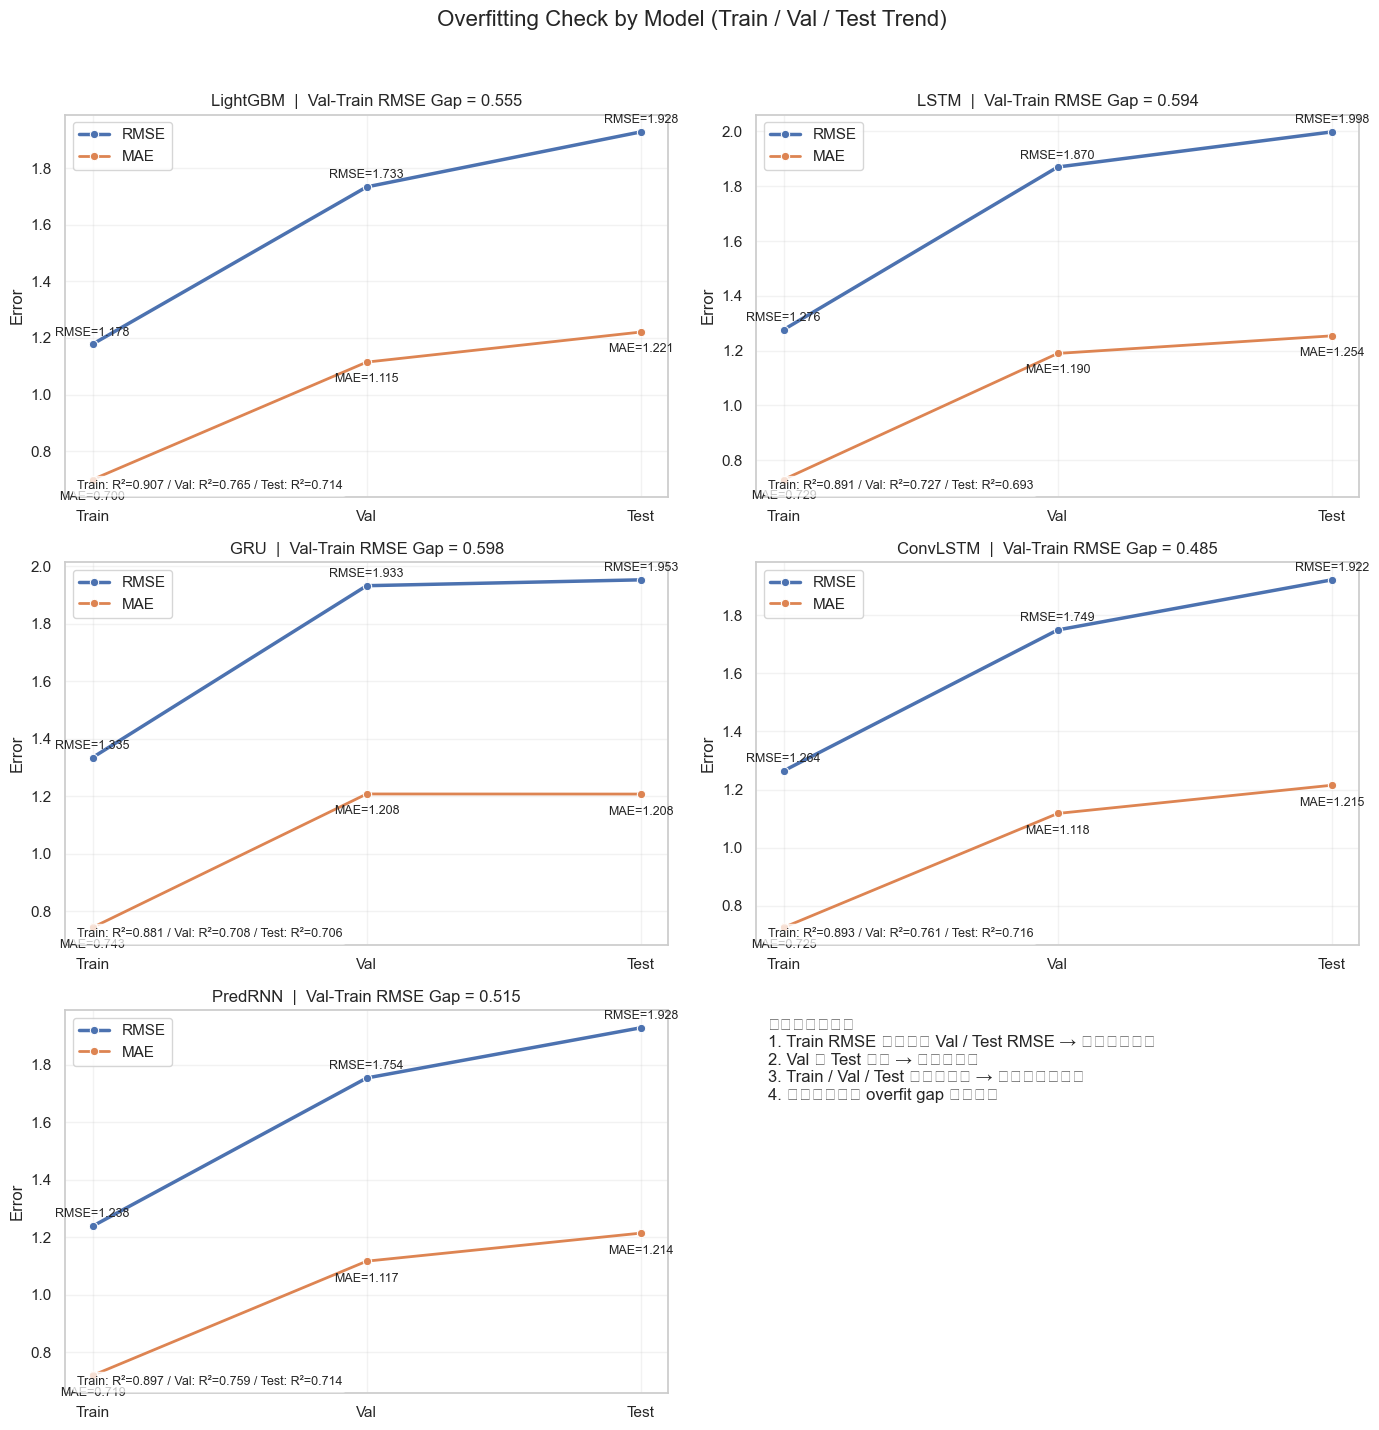

In [12]:
# 11. 五個模型各自的趨勢圖（看 Train / Val / Test 是否有過擬合）
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
split_order = ["Train", "Val", "Test"]
model_order = ["LightGBM", "LSTM", "GRU", "ConvLSTM", "PredRNN"]

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for idx, model_name in enumerate(model_order):
    ax = axes[idx]
    sub = df_all[df_all["Model"] == model_name].copy()
    sub["Split"] = pd.Categorical(sub["Split"], categories=split_order, ordered=True)
    sub = sub.sort_values("Split")

    sns.lineplot(data=sub, x="Split", y="RMSE", marker="o", linewidth=2.5, ax=ax, label="RMSE")
    sns.lineplot(data=sub, x="Split", y="MAE", marker="o", linewidth=2.0, ax=ax, label="MAE")

    # 標註數值
    for _, row in sub.iterrows():
        ax.text(row["Split"], row["RMSE"] + 0.02, f'RMSE={row["RMSE"]:.3f}', ha="center", va="bottom", fontsize=9)
        ax.text(row["Split"], row["MAE"] - 0.04, f'MAE={row["MAE"]:.3f}', ha="center", va="top", fontsize=9)

    rmse_gap = float(sub.loc[sub["Split"] == "Val", "RMSE"].iloc[0] - sub.loc[sub["Split"] == "Train", "RMSE"].iloc[0])
    r2_vals = sub["R²"].tolist()
    ax.set_title(f"{model_name}  |  Val-Train RMSE Gap = {rmse_gap:.3f}", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Error")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.25)

    # 右上角補 R² 趨勢摘要
    txt = " / ".join([f"{s}: R²={r:.3f}" for s, r in zip(sub["Split"], r2_vals)])
    ax.text(0.02, 0.02, txt, transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.75))

# 最後一格放判讀說明
axes[-1].axis("off")
axes[-1].text(
    0.02, 0.98,
    "如何看過擬合：\n"
    "1. Train RMSE 明顯低於 Val / Test RMSE → 有過擬合傾向\n"
    "2. Val 與 Test 接近 → 泛化較穩定\n"
    "3. Train / Val / Test 三者很接近 → 較不容易過擬合\n"
    "4. 也可搭配上方 overfit gap 表一起看",
    va="top", fontsize=12
)

plt.suptitle("Overfitting Check by Model (Train / Val / Test Trend)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# 已移除 RMSE bar chart / heatmap，改為五個模型各自的 Train / Val / Test 趨勢圖。

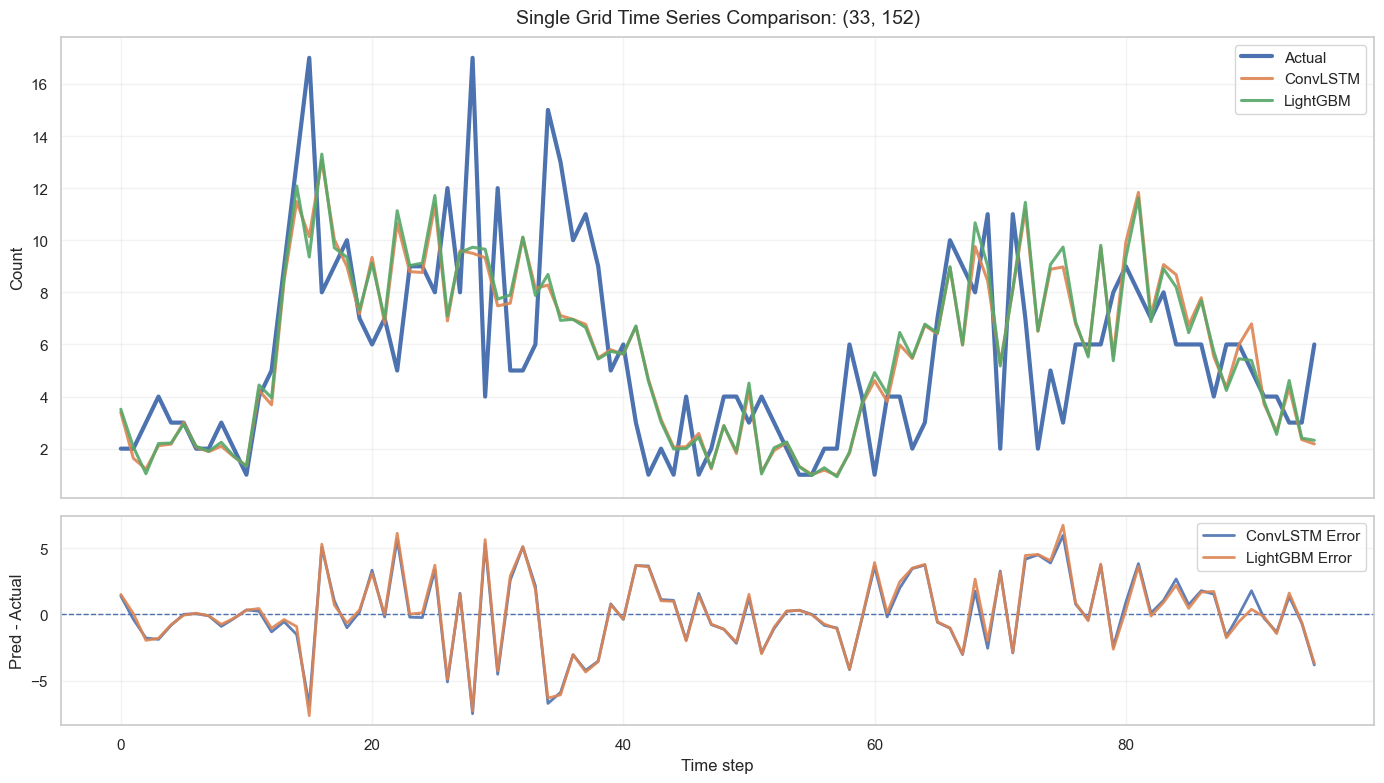

Grid = (33, 152), n = 96
ConvLSTM  RMSE on this grid: 2.802
LightGBM  RMSE on this grid: 2.848


In [15]:
# 12. 單一格點時間序列對比（Top 2：ConvLSTM vs LightGBM）

preds_top2 = {
    "ConvLSTM": y_pred_conv,
    "LightGBM": y_pred_lgbm,
}

# 用 test_df_seq，確保和預測陣列對齊
plot_df_source = test_df_seq.copy()

PLOT_X = int(plot_df_source["x"].mode().iloc[0])
PLOT_Y = int(plot_df_source["y"].mode().iloc[0])

target_df = (
    plot_df_source[(plot_df_source["x"] == PLOT_X) & (plot_df_source["y"] == PLOT_Y)]
    .sort_values(["d", "t"])
    .head(96)
    .copy()
)

if len(target_df) == 0:
    print(f"找不到 Grid ({PLOT_X}, {PLOT_Y}) 的資料")
else:
    idx = target_df.index.to_numpy()
    actual = target_df["count"].to_numpy()

    pred_conv = y_pred_conv[idx]
    pred_lgbm = y_pred_lgbm[idx]

    err_conv = pred_conv - actual
    err_lgbm = pred_lgbm - actual

    fig, axes = plt.subplots(
        2, 1, figsize=(14, 8), sharex=True,
        gridspec_kw={"height_ratios": [2.2, 1]}
    )

    # --- 上圖：Actual vs Prediction ---
    axes[0].plot(actual, linewidth=3, label="Actual")
    axes[0].plot(pred_conv, linewidth=2.2, label="ConvLSTM", alpha=0.9)
    axes[0].plot(pred_lgbm, linewidth=2.2, label="LightGBM", alpha=0.9)

    axes[0].set_title(f"Single Grid Time Series Comparison: ({PLOT_X}, {PLOT_Y})", fontsize=14, pad=10)
    axes[0].set_ylabel("Count")
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    # --- 下圖：Prediction Error ---
    axes[1].axhline(0, linestyle="--", linewidth=1)
    axes[1].plot(err_conv, linewidth=2, label="ConvLSTM Error", alpha=0.9)
    axes[1].plot(err_lgbm, linewidth=2, label="LightGBM Error", alpha=0.9)

    axes[1].set_xlabel("Time step")
    axes[1].set_ylabel("Pred - Actual")
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print(f"Grid = ({PLOT_X}, {PLOT_Y}), n = {len(target_df)}")
    print(f"ConvLSTM  RMSE on this grid: {np.sqrt(np.mean((pred_conv - actual) ** 2)):.3f}")
    print(f"LightGBM  RMSE on this grid: {np.sqrt(np.mean((pred_lgbm - actual) ** 2)):.3f}")